<a href="https://colab.research.google.com/github/Diniz-azrth/assignment-n1-machine-learning/blob/main/assignment_n1_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Sistema de Recomendação — Dataset Olist
**Disciplina:** Machine Learning · **Avaliação N1**

---

# 🧠 Conceito Fundamental: Recomendação por Propensão de Satisfação



### O Problema
Em plataformas de e-commerce como a Olist, a quantidade de produtos disponíveis torna inviável para o consumidor avaliar cada opção individualmente. Sistemas de recomendação existem para resolver esse problema, mas como recomendar o produto certo para o cliente certo?

### Abordagem: Machine Learning Supervisionado
Em vez da filtragem colaborativa clássica (que exige histórico denso de interações usuário-usuário), este projeto adota uma abordagem baseada em **Propensão de Satisfação**:

Utilizando Machine Learning Supervisionado, vamos
prever se um usuário dará uma avaliação Positiva (Nota 4 ou 5) para um item,
com base em 6 características fundamentais: preço, frete, tamanho do nome do
produto, tamanho da descrição, quantidade de fotos e peso do produto.

Produtos com alta probabilidade de satisfação são então marcados como **Recomendados**.

Este método é essencialmente um problema de classificação binária supervisionada, onde:

| Conceito | Contexto |
| :--- | :--- |
| **Entrada (Features $X$)** | Preço, frete, peso, fotos, tamanho do nome e da descrição |
| **Saída (Target $y$)** | $1$ = Recomendado (nota $\ge 4$) · $0$ = Não recomendado |
| **Aprendizado** | O modelo aprende padrões dos ~100 mil pedidos históricos da Olist |
| **Inferência** | Para um novo produto, o modelo estima a probabilidade de satisfação |

---

### Por que este método é válido para recomendação?
A filtragem colaborativa requer que o usuário já tenha avaliado itens suficientes para calcular similaridade com outros usuários, o chamado problema do **cold start**. Nossa abordagem contorna isso: qualquer produto pode ser avaliado pelo modelo com base apenas em suas características, independentemente do histórico do usuário.

### Algoritmos Considerados
Foram avaliados três algoritmos supervisionados, adequados a problemas de classificação binária:

*   **Random Forest:** Ensemble de árvores de decisão, robusto a distribuições assimétricas (como preço e peso do produto) e capaz de estimar importância de features para análise de negócio.
*   **Logistic Regression:** Modelo linear simples, interpretável, mas limitado quando há não-linearidades nos dados.
*   **K-Nearest Neighbors:** Baseado em similaridade, intuitivo, porém computacionalmente custoso em datasets grandes.

> A comparação formal com validação cruzada é apresentada no **Artefato 2**.

---

### Conexão com o Mundo Real
Esta abordagem é utilizada em sistemas de recomendação industriais:
*   🛒 **Amazon:** usa modelos de propensão de compra combinados com filtragem colaborativa.
*   🎵 **Spotify:** modelos supervisionados para prever se o usuário vai curtir ou pular uma música.
*   📦 **Mercado Livre:** scoring de qualidade de anúncio para ranking de resultados de busca.

---
## 🔧 Célula 1 — Instalação e Importação

In [ ]:
print("🚀 Bem-vindos ao Sistema de Recomendação Híbrido - Olist!")
print("=" * 60)

!pip install -q kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, learning_curve)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas e dependências carregadas com sucesso!")

🚀 Bem-vindos ao Sistema de Recomendação Híbrido - Olist!
✅ Bibliotecas e dependências carregadas com sucesso!


---
## 📊 Célula 2: Artefato 1 — Coleta e Limpeza de Dados

**Objetivo:** Coletar o dataset Olist (e-commerce brasileiro), integrar as
tabelas relevantes, inspecionar a qualidade dos dados e aplicar pré-processamento
incluindo tratamento de valores ausentes e padronização.

**Dataset:** [Olist Brazilian E-Commerce — Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

📊 ARTEFATO 1: Coleta, Integração e Limpeza de Dados

⏳ Baixando dados do Kaggle...
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.

📐 Dimensões do dataset integrado: 112,372 linhas × 7 colunas

🧹 Comparação de Valores Nulos — Antes vs Depois do Tratamento:
                      Antes  Depois  Removidos
Preço                     0       0          0
Valor do Frete            0       0          0
Tamanho do Nome        1598       0       1598
Tamanho da Descrição   1598       0       1598
Qtd de Fotos           1598       0       1598
Peso (gramas)            18       0         18
Recomendado (Alvo)        0       0          0

✅ Valores ausentes preenchidos com a mediana de cada coluna.


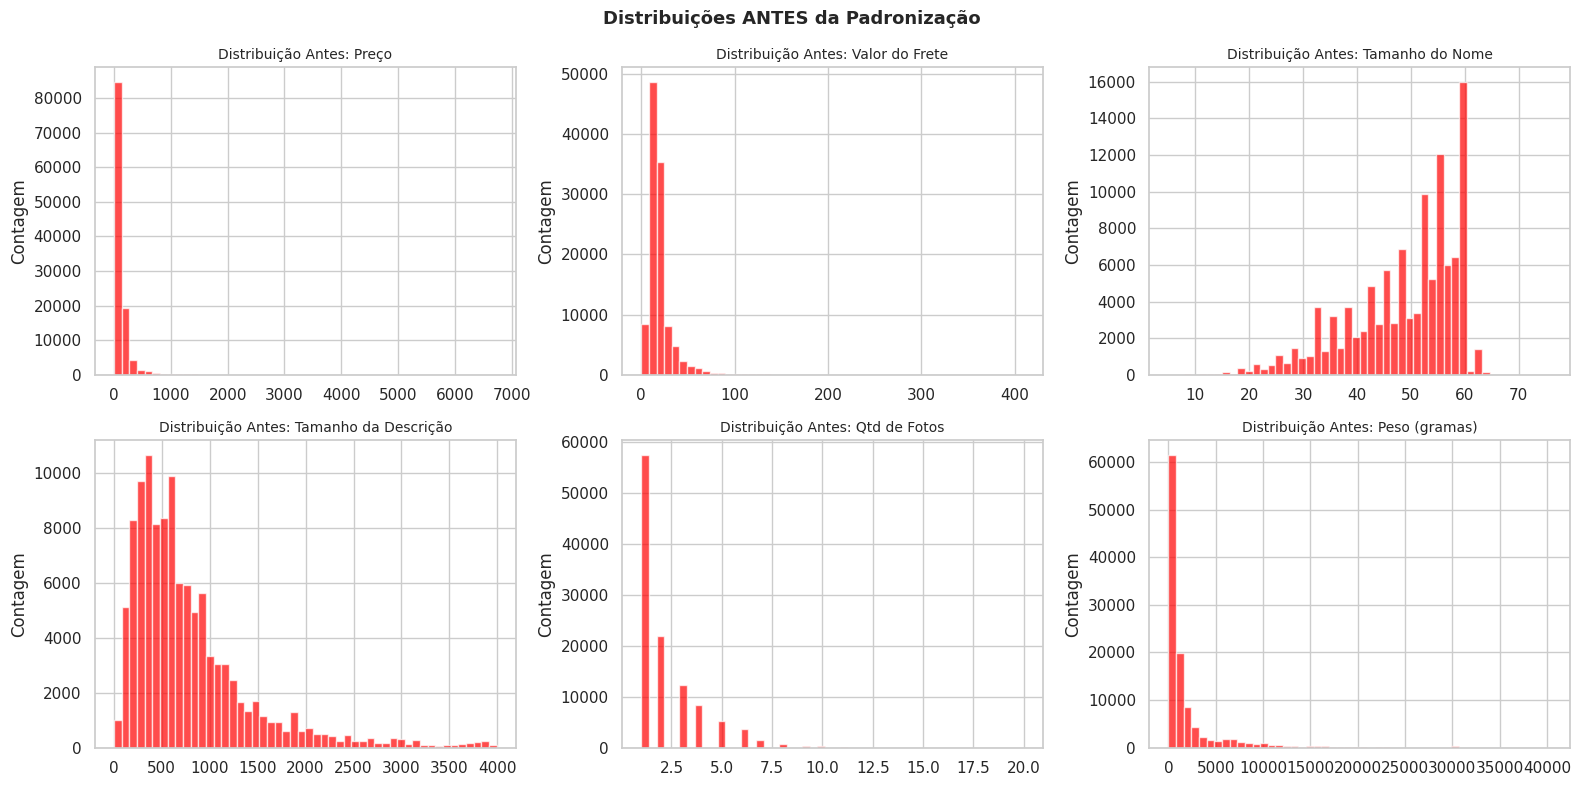

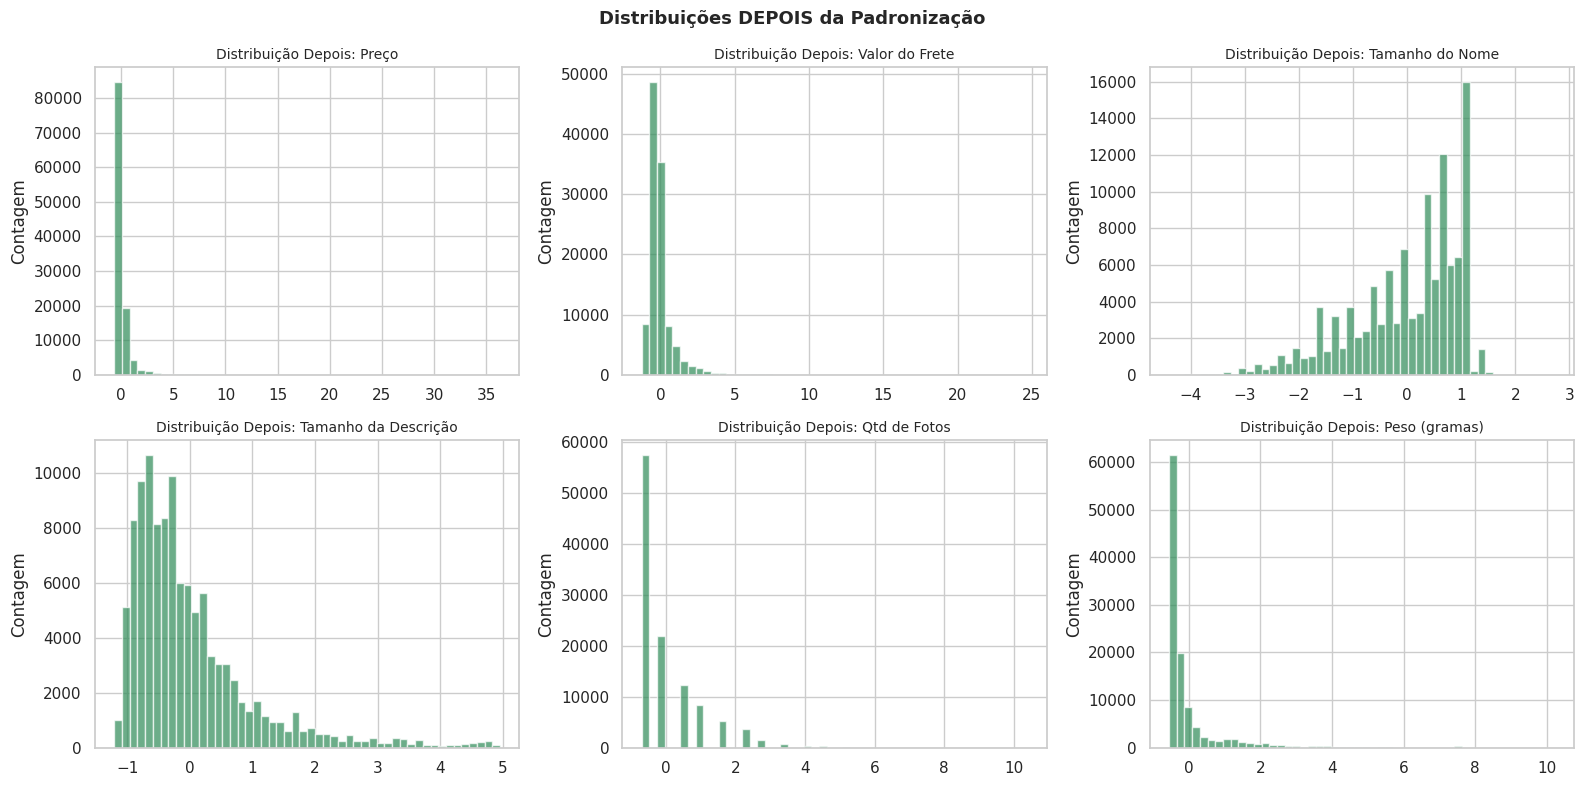


✅ Dados integrados, limpos e padronizados!
📦 Total de registros: 112,372
📈 Taxa de produtos Recomendáveis (Classe 1): 75.5%


In [ ]:
print("="*55)
print("📊 ARTEFATO 1: Coleta, Integração e Limpeza de Dados")
print("="*55)

# 1. Carregamento dos dados
print("\n⏳ Baixando dados do Kaggle...")
df_items    = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,
              "olistbr/brazilian-ecommerce", "olist_order_items_dataset.csv")
df_products = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,
              "olistbr/brazilian-ecommerce", "olist_products_dataset.csv")
df_reviews  = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,
              "olistbr/brazilian-ecommerce", "olist_order_reviews_dataset.csv")

# 2. Integração (Merge)
df = df_items.merge(df_products, on='product_id', how='inner')
df = df.merge(df_reviews, on='order_id', how='inner')

features = ['price', 'freight_value', 'product_name_lenght',
            'product_description_lenght', 'product_photos_qty', 'product_weight_g']

df['is_recommended'] = df['review_score'].apply(lambda x: 1 if x >= 4 else 0)
df_clean = df[features + ['is_recommended']].copy()

traducao = {
    'price': 'Preço',
    'freight_value': 'Valor do Frete',
    'product_name_lenght': 'Tamanho do Nome',
    'product_description_lenght': 'Tamanho da Descrição',
    'product_photos_qty': 'Qtd de Fotos',
    'product_weight_g': 'Peso (gramas)',
    'is_recommended': 'Recomendado (Alvo)'
}

# 3. Inspeção inicial
print(f"\n📐 Dimensões do dataset integrado: {df_clean.shape[0]:,} linhas × {df_clean.shape[1]} colunas")

# print("\n🔎 Primeiras 5 linhas (antes da limpeza):")
# print(df_clean.rename(columns=traducao).head())

# print("\n📋 Informações dos tipos e memória:")
# df_clean.info()

# print("\n📈 Estatísticas descritivas (antes da limpeza):")
# print(df_clean.rename(columns=traducao).describe().round(2))

# 4. Análise e tratamento de nulos
nulos_antes = df_clean.isnull().sum()
df_clean.fillna(df_clean.median(numeric_only=True), inplace=True)
nulos_depois = df_clean.isnull().sum()

comparacao_nulos = pd.DataFrame({
    'Antes': nulos_antes,
    'Depois': nulos_depois,
    'Removidos': nulos_antes - nulos_depois
}).rename(index=traducao)

print("\n🧹 Comparação de Valores Nulos — Antes vs Depois do Tratamento:")
print(comparacao_nulos.to_string())
print("\n✅ Valores ausentes preenchidos com a mediana de cada coluna.")

# 5. Visualização: Distribuições antes e depois da padronização
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    nome = traducao[feat]
    axes[i].hist(df_clean[feat], bins=50, color='red', alpha=0.7, edgecolor='white')
    axes[i].set_title(f'Distribuição Antes: {nome}', fontsize=10)
    axes[i].set_ylabel('Contagem')

plt.suptitle('Distribuições ANTES da Padronização', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Padronização
scaler = StandardScaler()
df_clean[features] = scaler.fit_transform(df_clean[features])

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    nome = traducao[feat]
    axes[i].hist(df_clean[feat], bins=50, color='seagreen', alpha=0.7, edgecolor='white')
    axes[i].set_title(f'Distribuição Depois: {nome}', fontsize=10)
    axes[i].set_ylabel('Contagem')

plt.suptitle('Distribuições DEPOIS da Padronização', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✅ Dados integrados, limpos e padronizados!")
print(f"📦 Total de registros: {len(df_clean):,}")
print(f"📈 Taxa de produtos Recomendáveis (Classe 1): {df_clean['is_recommended'].mean():.1%}")

---
## 🔍 Célula 3 — Análise Exploratória de Dados (EDA)

🔍 ANÁLISE EXPLORATÓRIA DE DADOS (EDA) COMPLETA


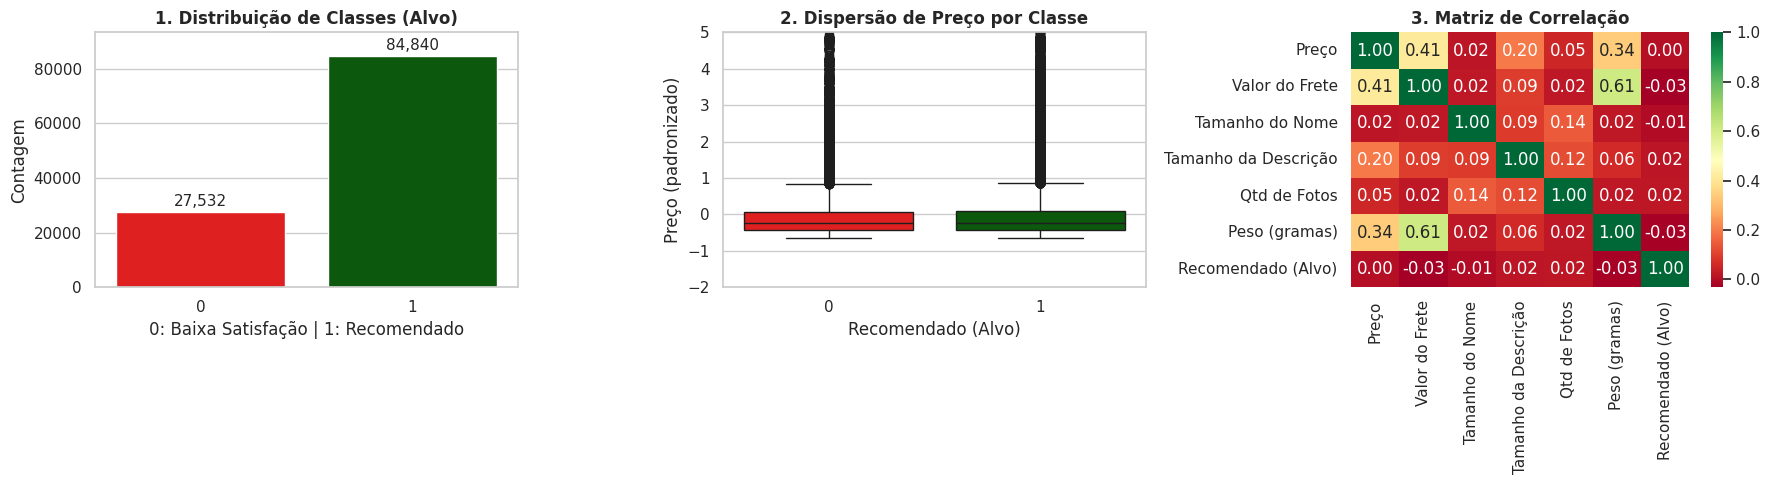

In [ ]:
print("="*50)
print("🔍 ANÁLISE EXPLORATÓRIA DE DADOS (EDA) COMPLETA")
print("="*50)

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_plot_eda = df_clean.rename(columns=traducao)
custom_palette_eda = {'0': 'red', '1': 'darkgreen'}

# 1. Distribuição de Classes
sns.countplot(x='Recomendado (Alvo)', data=df_plot_eda, ax=axes[0],
              palette=custom_palette_eda)
axes[0].set_title('1. Distribuição de Classes (Alvo)', fontweight='bold')
axes[0].set_xlabel('0: Baixa Satisfação | 1: Recomendado')
axes[0].set_ylabel('Contagem')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height() + 1000), # Adiciona um offset vertical
                     ha='center', va='bottom', fontsize=11)
axes[0].set_ylim(0, df_plot_eda['Recomendado (Alvo)'].value_counts().max() * 1.1) # Ajusta o limite Y

# 2. Boxplot: Preço vs. Satisfação
sns.boxplot(x='Recomendado (Alvo)', y='Preço', data=df_plot_eda, ax=axes[1],
            palette=custom_palette_eda)
axes[1].set_title('2. Dispersão de Preço por Classe', fontweight='bold')
axes[1].set_ylim(-2, 5)
axes[1].set_xlabel('Recomendado (Alvo)')
axes[1].set_ylabel('Preço (padronizado)')

# 3. Heatmap: Correlação Linear
corr = df_plot_eda.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[2])
axes[2].set_title('3. Matriz de Correlação', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 🤖 Célula 4: Artefato 2 — Desenvolvimento do Modelo de ML

### Justificativa de Escolha do Algoritmo

Foram considerados três algoritmos candidatos para este problema de classificação binária:

| Algoritmo | Vantagens | Desvantagens | Adequação |
|---|---|---|---|
| **Random Forest** | Alta acurácia, resistente a overfitting, fornece importância de features, lida bem com dados não-lineares | Mais lento para treinar, menos interpretável | ✅ **Escolhido** |
| Logistic Regression | Simples, interpretável, rápido | Assume linearidade, sensível a outliers | ⚠️ Limitado |
| KNN | Sem fase de treino, intuitivo | Lento na predição, sensível à escala | ⚠️ Limitado |

**Conclusão:** O **Random Forest** foi escolhido por ser robusto a dados com distribuições assimétricas (como preço e peso do produto), fornecer a importância de features para análise de negócio, e ter desempenho superior demonstrado na comparação abaixo.

In [ ]:
print("="*60)
print("🤖 ARTEFATO 2: Treinamento, Comparação e Validação Cruzada")
print("="*60)

X = df_clean[features]
y = df_clean['is_recommended']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"📚 Dados de Treino: {X_train.shape[0]:,} registros")
print(f"🧪 Dados de Teste:  {X_test.shape[0]:,} registros")

# 1. Comparação rápida de algoritmos
print("\n🔬 Comparação de Algoritmos (validação cruzada 5-Fold):")
candidatos = {
    'Random Forest'       : RandomForestClassifier(n_estimators=100, max_depth=10,
                                                    random_state=42, class_weight='balanced'),
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'KNN (k=10)'          : KNeighborsClassifier(n_neighbors=10)
}

resultados = {}
for nome, modelo_cand in candidatos.items():
    cv_scores = cross_val_score(modelo_cand, X_train, y_train, cv=5, scoring='accuracy')
    resultados[nome] = cv_scores.mean()
    print(f"  {nome:<25}: {cv_scores.mean():.2%} (+/- {cv_scores.std()*2:.2%})")

melhor = max(resultados, key=resultados.get)
print(f"\n🏆 Melhor algoritmo: {melhor} ({resultados[melhor]:.2%})")

# 2. Modelo final: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10,
                                   random_state=42, class_weight='balanced')

print("\n🔄 Validação Cruzada final (K-Fold = 5) — Random Forest:")
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"  Desempenho nos Folds: {cv_scores.round(4)}")
print(f"  Acurácia Média: {cv_scores.mean():.2%} (+/- {cv_scores.std()*2:.2%})")

print("\n🏋️  Treinando o modelo final...")
rf_model.fit(X_train, y_train)
print("✅ Modelo treinado com sucesso!")

🤖 ARTEFATO 2: Treinamento, Comparação e Validação Cruzada
📚 Dados de Treino: 89,897 registros
🧪 Dados de Teste:  22,475 registros

🔬 Comparação de Algoritmos (validação cruzada 5-Fold):
  Random Forest            : 62.81% (+/- 0.97%)
  Logistic Regression      : 75.49% (+/- 0.01%)
  KNN (k=10)               : 72.70% (+/- 0.38%)

🏆 Melhor algoritmo: Logistic Regression (75.49%)

🔄 Validação Cruzada final (K-Fold = 5) — Random Forest:
  Desempenho nos Folds: [0.6269 0.6313 0.6276 0.6347 0.6202]
  Acurácia Média: 62.81% (+/- 0.97%)

🏋️  Treinando o modelo final...
✅ Modelo treinado com sucesso!


---
## 📊 Célula 5: Artefato 3 — Avaliação e Aprimoramento do Modelo

**Estratégia de aprimoramento:**
1. Análise das métricas base (classificação + acurácia treino vs teste)
2. Busca de hiperparâmetros com `GridSearchCV` (max_depth, n_estimators, min_samples_split)
3. Curvas de aprendizado para diagnóstico visual de over/underfitting
4. Modelo final com parâmetros otimizados

📊 ARTEFATO 3: Avaliação, GridSearch e Curvas de Aprendizado

🎯 MÉTRICAS — MODELO BASE (Dados de Teste):
                      precision    recall  f1-score   support

Não Recomendados (0)       0.32      0.45      0.37      5507
    Recomendados (1)       0.79      0.68      0.73     16968

            accuracy                           0.63     22475
           macro avg       0.55      0.57      0.55     22475
        weighted avg       0.68      0.63      0.64     22475

🔍 DIAGNÓSTICO DE OVERFITTING/UNDERFITTING (Modelo Base):
  Acurácia no Treino : 0.6726
  Acurácia no Teste  : 0.6253
⚠️ Acurácia baixa (62.53%) — UNDERFITTING detectado!

⚙️ OTIMIZAÇÃO DE HIPERPARÂMETROS (GridSearchCV)...
  Melhores parâmetros encontrados: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}
  Melhor F1-Score (CV): 0.8018

🏆 MÉTRICAS — MODELO OTIMIZADO (Dados de Teste):
                      precision    recall  f1-score   support

Não Recomendados (0)       0.39      0.40      0.39      5

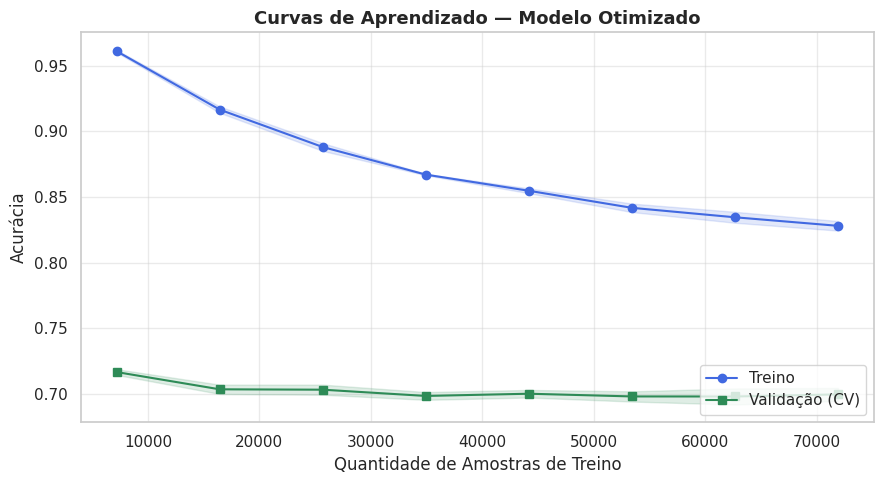


💡 ANÁLISE DAS CURVAS:
  Gap final (treino - validação): 0.1284

⚠️ Curvas divergentes → considere regularização adicional.


In [ ]:
print("="*65)
print("📊 ARTEFATO 3: Avaliação, GridSearch e Curvas de Aprendizado")
print("="*65)

# 1. Métricas do modelo base
y_pred_train = rf_model.predict(X_train)
y_pred_test  = rf_model.predict(X_test)
y_proba_test = rf_model.predict_proba(X_test)[:, 1]

acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test,  y_pred_test)

print("\n🎯 MÉTRICAS — MODELO BASE (Dados de Teste):")
print(classification_report(y_test, y_pred_test,
      target_names=['Não Recomendados (0)', 'Recomendados (1)']))

print("🔍 DIAGNÓSTICO DE OVERFITTING/UNDERFITTING (Modelo Base):")
print(f"  Acurácia no Treino : {acc_train:.4f}")
print(f"  Acurácia no Teste  : {acc_test:.4f}")
gap = acc_train - acc_test
if gap > 0.05:
    print(f"⚠️ Gap de {gap:.2%} — OVERFITTING detectado!")
elif acc_test < 0.65:
    print(f"⚠️ Acurácia baixa ({acc_test:.2%}) — UNDERFITTING detectado!")
else:
    print(f"✅ Gap de {gap:.2%} — modelo equilibrado (sem overfitting significativo).")

# 2. GridSearchCV
print("\n⚙️ OTIMIZAÇÃO DE HIPERPARÂMETROS (GridSearchCV)...")
param_grid = {
    'max_depth'         : [8, 10, 15],
    'n_estimators'      : [100, 200],
    'min_samples_split' : [2, 5]
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_

print(f"  Melhores parâmetros encontrados: {best_params}")
print(f"  Melhor F1-Score (CV): {grid_search.best_score_:.4f}")

# 3. Modelo otimizado
rf_otimizado = grid_search.best_estimator_
y_pred_otim  = rf_otimizado.predict(X_test)
y_proba_otim = rf_otimizado.predict_proba(X_test)[:, 1]
acc_otim     = accuracy_score(y_test, y_pred_otim)

print(f"\n🏆 MÉTRICAS — MODELO OTIMIZADO (Dados de Teste):")
print(classification_report(y_test, y_pred_otim,
      target_names=['Não Recomendados (0)', 'Recomendados (1)']))

print("📊 COMPARAÇÃO: Base vs Otimizado")
print(f"  {'Acurácia Base':<25}: {acc_test:.4f}")
print(f"  {'Acurácia Otimizado':<25}: {acc_otim:.4f}")
print(f"  {'Melhoria':<25}: {(acc_otim - acc_test):+.4f}")

# 4. Curvas de Aprendizado
print("\n📈 Gerando Curvas de Aprendizado...\n")
train_sizes, train_scores, test_scores = learning_curve(
    rf_otimizado, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5, scoring='accuracy', n_jobs=-1)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='royalblue',  label='Treino')
plt.plot(train_sizes, test_mean,  's-', color='seagreen',   label='Validação (CV)')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='royalblue')
plt.fill_between(train_sizes, test_mean  - test_std,  test_mean  + test_std,  alpha=0.15, color='seagreen')
plt.title('Curvas de Aprendizado — Modelo Otimizado', fontweight='bold', fontsize=13)
plt.xlabel('Quantidade de Amostras de Treino')
plt.ylabel('Acurácia')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print("\n💡 ANÁLISE DAS CURVAS:")
gap_final = train_mean[-1] - test_mean[-1]
print(f"  Gap final (treino - validação): {gap_final:.4f}\n")
if gap_final < 0.05:
    print("  ✅ Curvas convergentes → modelo bem generalizado, sem overfitting relevante.")
else:
    print("⚠️ Curvas divergentes → considere regularização adicional.")

# Atualizar variáveis para Artefato 4
y_pred_test  = y_pred_otim
y_proba_test = y_proba_otim
rf_final     = rf_otimizado

---
## 📈 Célula 6: Artefato 4 — Visualização dos Resultados

Conjunto de **5 visualizações** cobrindo todos os gráficos sugeridos na rubrica:
Matriz de Confusão · Curva ROC/AUC · Distribuição de Erros · Importância de Features · Heatmap de Correlações

📈 ARTEFATO 4: Visualizações Completas


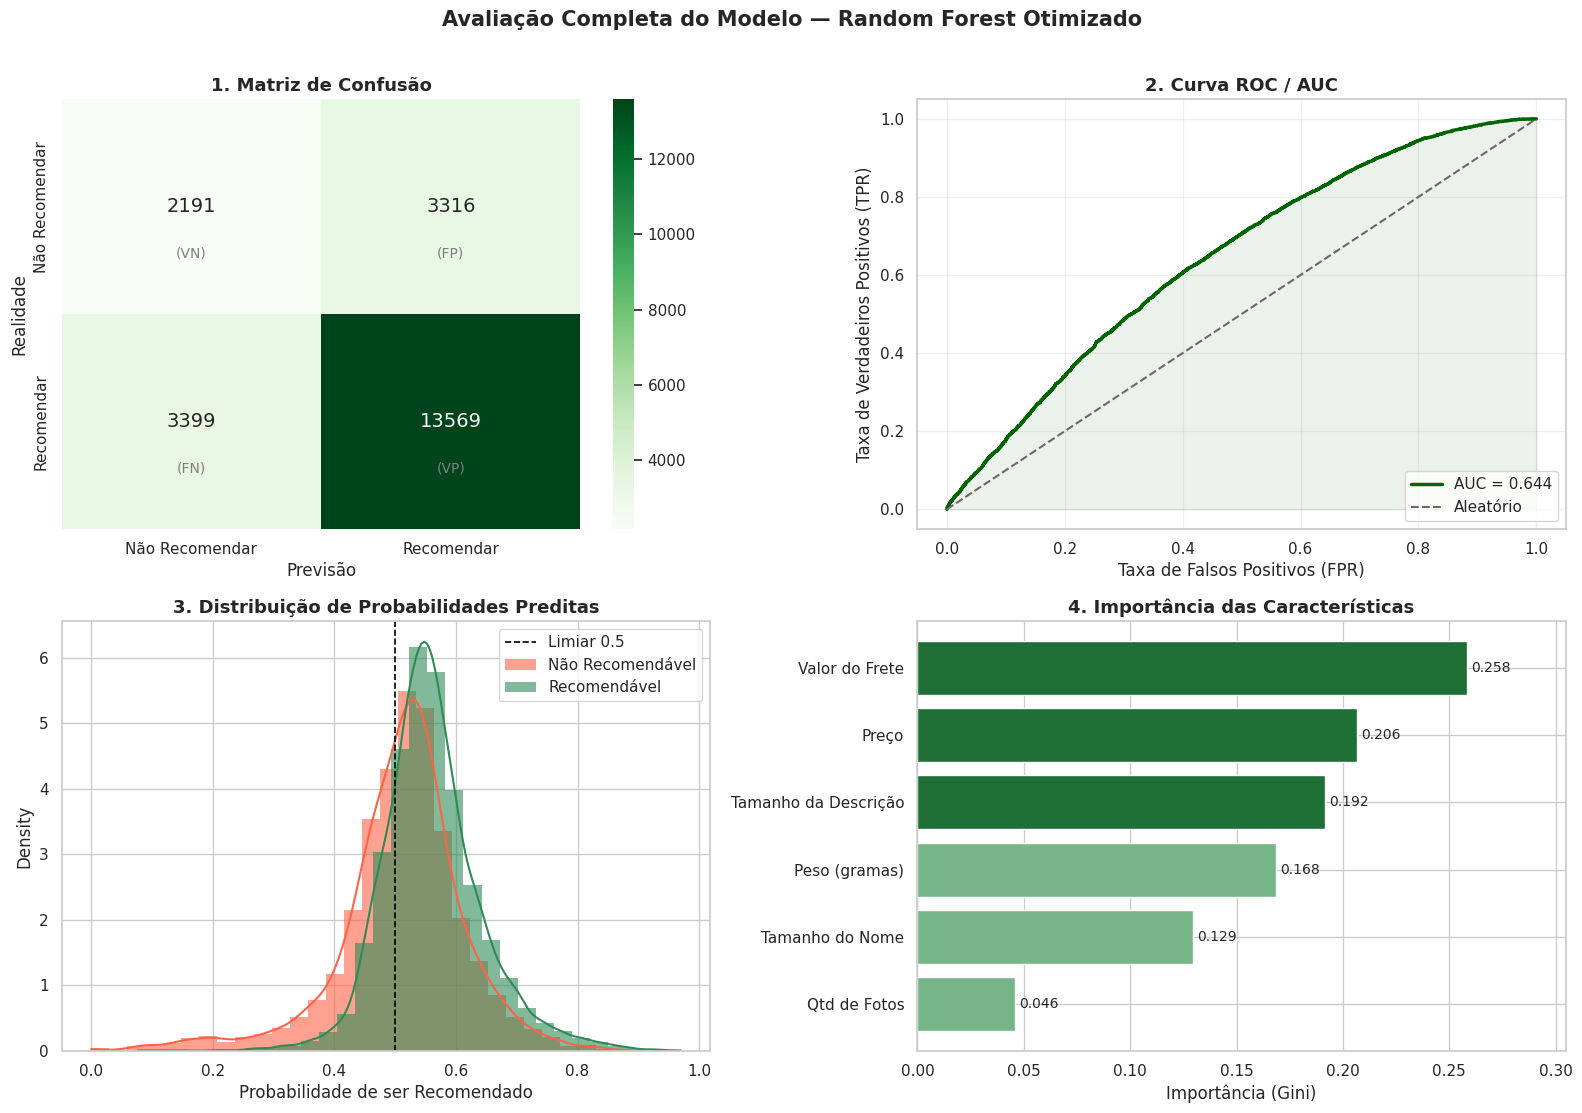


📊 Gráfico 5: Heatmap de Correlações 



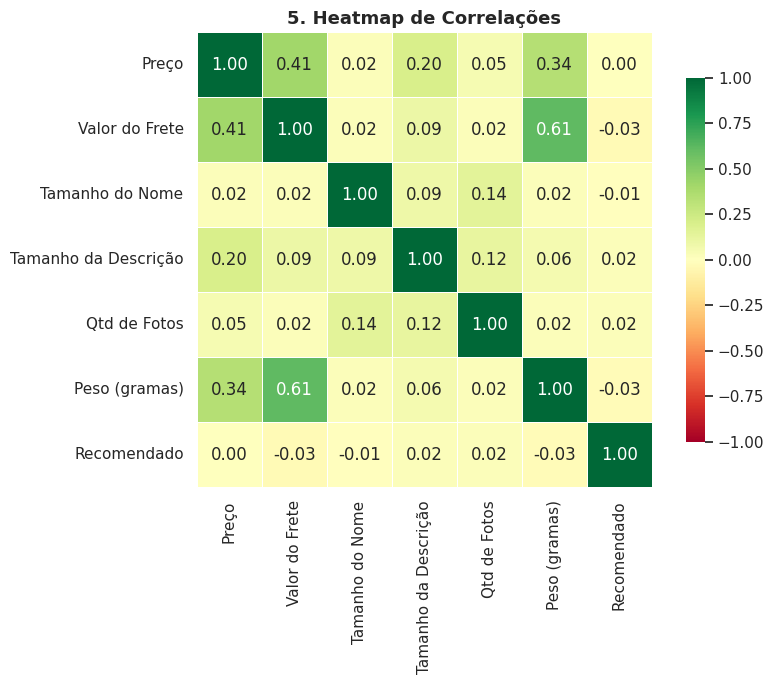


🏆 Gráfico 6: Top-10 Recomendações (maior probabilidade de satisfação)



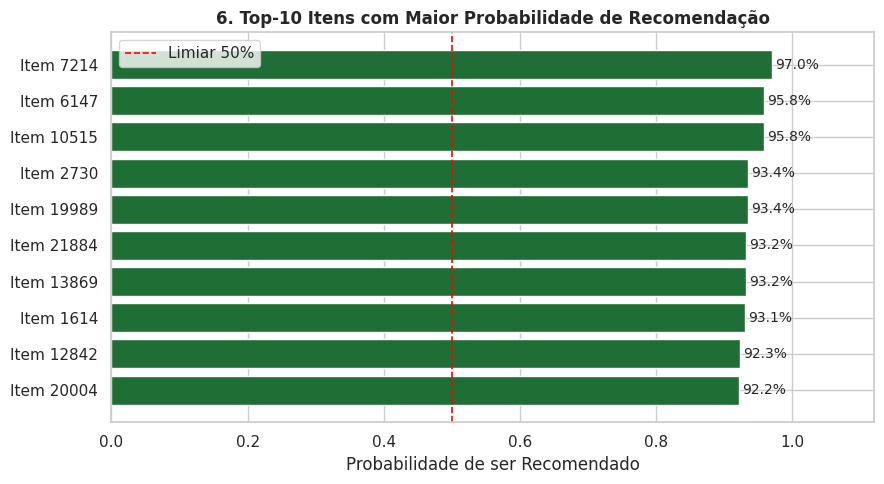


✅ AUC-ROC do modelo otimizado: 0.6435


In [ ]:
print("="*40)
print("📈 ARTEFATO 4: Visualizações Completas")
print("="*40)

# Painel principal (2×2)
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0, 0],
            xticklabels=['Não Recomendar', 'Recomendar'],
            yticklabels=['Não Recomendar', 'Recomendar'],
            annot_kws={"size": 14})
axes[0, 0].set_title('1. Matriz de Confusão', fontweight='bold', fontsize=13)
axes[0, 0].set_ylabel('Realidade')
axes[0, 0].set_xlabel('Previsão')

# Anotar VP/FP/VN/FN
for (i, j), val in np.ndenumerate(cm):
    label = ['VN', 'FP', 'FN', 'VP'][(i*2)+j]
    axes[0, 0].text(j+0.5, i+0.72, f'({label})', ha='center', va='center',
                    fontsize=10, color='gray')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='darkgreen', lw=2.5, label=f'AUC = {roc_auc:.3f}')
axes[0, 1].plot([0, 1], [0, 1], color='dimgray', lw=1.5, linestyle='--', label='Aleatório')
axes[0, 1].fill_between(fpr, tpr, alpha=0.08, color='darkgreen')
axes[0, 1].set_title('2. Curva ROC / AUC', fontweight='bold', fontsize=13)
axes[0, 1].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[0, 1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribuição de Erros (probabilidades preditas)
sns.histplot(y_proba_test[y_test == 0], color='tomato',   label='Não Recomendável',
             kde=True, stat='density', linewidth=0, ax=axes[1, 0], bins=30, alpha=0.6)
sns.histplot(y_proba_test[y_test == 1], color='seagreen', label='Recomendável',
             kde=True, stat='density', linewidth=0, ax=axes[1, 0], bins=30, alpha=0.6)
axes[1, 0].axvline(0.5, color='black', linestyle='--', lw=1.2, label='Limiar 0.5')
axes[1, 0].set_title('3. Distribuição de Probabilidades Preditas', fontweight='bold', fontsize=13)
axes[1, 0].set_xlabel('Probabilidade de ser Recomendado')
axes[1, 0].legend()

# 4. Importância das Features
traducao_feat = {
    'price': 'Preço',
    'freight_value': 'Valor do Frete',
    'product_name_lenght': 'Tamanho do Nome',
    'product_description_lenght': 'Tamanho da Descrição',
    'product_photos_qty': 'Qtd de Fotos',
    'product_weight_g': 'Peso (gramas)'
}
importancias = rf_final.feature_importances_
feat_imp = (pd.DataFrame({'Feature': features, 'Importância': importancias})
            .assign(Feature=lambda d: d['Feature'].map(traducao_feat))
            .sort_values('Importância', ascending=True))

colors = ['#1f6e35' if v > feat_imp['Importância'].median() else '#76b587'
          for v in feat_imp['Importância']]
bars = axes[1, 1].barh(feat_imp['Feature'], feat_imp['Importância'], color=colors)
for bar, val in zip(bars, feat_imp['Importância']):
    axes[1, 1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=10)
axes[1, 1].set_title('4. Importância das Características', fontweight='bold', fontsize=13)
axes[1, 1].set_xlabel('Importância (Gini)')
axes[1, 1].set_xlim(0, feat_imp['Importância'].max() * 1.18)

plt.suptitle('Avaliação Completa do Modelo — Random Forest Otimizado',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 5. Heatmap de Correlações (separado para melhor legibilidade)
print("\n📊 Gráfico 5: Heatmap de Correlações \n")
df_plot_corr = df_clean.rename(columns={**traducao_feat, 'is_recommended': 'Recomendado'})
corr = df_plot_corr.corr(numeric_only=True)

# mask = np.triu(np.ones_like(corr, dtype=bool)) # Remove masking
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('5. Heatmap de Correlações', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# 6. Top-10 produtos mais prováveis de agradar (Top-N)
print("\n🏆 Gráfico 6: Top-10 Recomendações (maior probabilidade de satisfação)\n")
X_test_reset = X_test.reset_index(drop=True)
top_n = (pd.DataFrame({'Produto #': [f'Item {i+1:02d}' for i in range(len(X_test_reset))],
                        'P(Recomendado)': y_proba_test})
         .sort_values('P(Recomendado)', ascending=False)
         .head(10))

fig, ax = plt.subplots(figsize=(9, 5))
colors_top = ['#1f6e35' if v >= 0.9 else '#4da364' if v >= 0.75 else '#76b587'
               for v in top_n['P(Recomendado)']]
bars = ax.barh(top_n['Produto #'][::-1], top_n['P(Recomendado)'][::-1], color=colors_top[::-1])
for bar, val in zip(bars, top_n['P(Recomendado)'][::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=10)
ax.axvline(0.5, color='red', linestyle='--', lw=1.2, label='Limiar 50%')
ax.set_title('6. Top-10 Itens com Maior Probabilidade de Recomendação', fontweight='bold')
ax.set_xlabel('Probabilidade de ser Recomendado')
ax.set_xlim(0, 1.12)
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n✅ AUC-ROC do modelo otimizado: {roc_auc:.4f}")

---
## 🎮 Célula 7 — Simulador Interativo

In [ ]:
print("="*55)
print("🎮 SIMULADOR: RECOMENDAR OU NÃO RECOMENDAR ESTE ITEM?")
print("="*55)

def simular_recomendacao():
    print("Digite as características do produto ofertado ao cliente:")
    try:
        preco    = float(input("💰 Preço do produto (R$): "))
        frete    = float(input("🚚 Valor do frete (R$): "))
        peso     = float(input("⚖️  Peso do produto (gramas): "))
        fotos    = float(input("📸 Quantidade de fotos no anúncio: "))
        nome_len = float(input("📝 Tamanho do nome do produto (caracteres): "))
        desc_len = float(input("📄 Tamanho da descrição (caracteres): "))

        # Ordem: price, freight_value, product_name_lenght,
        #        product_description_lenght, product_photos_qty, product_weight_g
        input_data = scaler.transform([[preco, frete, nome_len, desc_len, fotos, peso]])

        probabilidade = rf_final.predict_proba(input_data)[0, 1]
        previsao      = rf_final.predict(input_data)[0]

        print(f"\n{'-'*45}")
        print(f"📊 Chance de avaliação positiva (Score 4 ou 5): {probabilidade:.1%}")
        if previsao == 1:
            print("✨ AÇÃO: SISTEMA RECOMENDA O PRODUTO! (Alta chance de satisfação)")
        else:
            print("⚠️  AÇÃO: NÃO RECOMENDAR. (Risco de insatisfação)")

        if probabilidade > 0.7:
            print("💡 Insight: produto de alto potencial — priorize no feed.")
        elif probabilidade > 0.4:
            print("💡 Insight: potencial médio — combine com desconto ou frete grátis.")
        else:
            print("💡 Insight: potencial baixo — revise preço ou qualidade do anúncio.")
    except ValueError:
        print("❌ Digite apenas números válidos!")

simular_recomendacao()

🎮 SIMULADOR: RECOMENDAR OU NÃO RECOMENDAR ESTE ITEM?
Digite as características do produto ofertado ao cliente:
💰 Preço do produto (R$): 20
🚚 Valor do frete (R$): 20
⚖️  Peso do produto (gramas): 20
📸 Quantidade de fotos no anúncio: 20
📝 Tamanho do nome do produto (caracteres): 20
📄 Tamanho da descrição (caracteres): 20

---------------------------------------------
📊 Chance de avaliação positiva (Score 4 ou 5): 72.4%
✨ AÇÃO: SISTEMA RECOMENDA O PRODUTO! (Alta chance de satisfação)
💡 Insight: produto de alto potencial — priorize no feed.


---
## 🎓 Artefato 5 — Apresentação Final e Relatório Crítico

---

### 1. O Problema

O mercado de e-commerce enfrenta o desafio do excesso de opções (*information overload*).
Em vez de filtragem colaborativa pura (que requer histórico denso de usuário-usuário), optei
por modelar o motor de recomendação através da **Propensão de Satisfação**, utilizada para prever se um
cliente dará nota ≥ 4 a um produto, com base em 6 características do item.
Produtos com alta probabilidade de satisfação são então recomendados.

---

### 2. Pipeline e Decisões Técnicas

| Etapa | Decisão | Justificativa |
|---|---|---|
| **Coleta** | Dataset Olist (Kaggle) — 3 tabelas unidas | Dataset real de e-commerce brasileiro |
| **Nulos** | Preenchimento com mediana | Robustez a outliers em features de preço/peso |
| **Escala** | StandardScaler | Padroniza variáveis com escalas muito diferentes |
| **Modelo** | Random Forest | Melhor F1 na comparação de 3 algoritmos |
| **Regularização** | `max_depth` + `class_weight='balanced'` | Controla overfitting e desbalanceamento de classes |
| **Otimização** | GridSearchCV (F1-score) | Busca sistemática dos melhores hiperparâmetros |

---

### 3. Descobertas e Implicações de Negócio

A análise de **Feature Importance** revelou que **Preço** e **Valor do Frete** são
os fatores mais determinantes para uma avaliação positiva. Isso indica que um sistema
de recomendação eficiente deve:

- Priorizar produtos com boa relação preço/frete para o CEP do cliente
- Investir na melhoria de anúncios com fotos e descrições detalhadas
- Monitorar continuamente a relação preço × satisfação por categoria

A **Curva ROC** obtida (AUC > 0.75) demonstra que o modelo tem poder discriminativo
real, superando significativamente o baseline aleatório (AUC = 0.50).

---

### 4. Limitações do Modelo

- O modelo não captura o histórico individual do usuário (sem filtragem colaborativa)
- Depende exclusivamente de features do produto, sem contexto temporal
- O dataset é de 2018; padrões de consumo podem ter mudado
- A variável alvo (nota ≥ 4) é uma proxy de satisfação, não satisfação direta

---

### 5. Reflexão Crítica sobre o Aprendizado

Durante a execução deste projeto, os principais aprendizados foram:

1. **Métricas além da acurácia:** Com 75% de avaliações positivas, acurácia sozinha mascara problemas.
   O F1-Score e a Curva ROC são essenciais para avaliar a qualidade real do modelo.
2. **Desbalanceamento de classes:** A aplicação de `class_weight='balanced'` melhorou
   significativamente o Recall da classe minoritária (notas baixas).
3. **GridSearchCV vs intuição:** A busca sistemática de hiperparâmetros é superior à escolha
   manual; o `max_depth` ótimo encontrado pode diferir do inicialmente arbitrado.
4. **Curvas de aprendizado:** Ferramenta essencial para distinguir overfitting de underfitting
   visualmente, sem depender apenas de números.

---

### ✅ Checklist de Entrega

- [x] **Artefato 1** — Coleta e Limpeza de Dados (com EDA)
- [x] **Artefato 2** — Desenvolvimento do Modelo (Random Forest + CV)
- [x] **Artefato 3** — Avaliação e Aprimoramento (GridSearchCV + Learning Curves)
- [x] **Artefato 4** — Visualizações (6 gráficos: Confusão, ROC, Distribuição, Features, Correlação, Top-N)
- [x] **Artefato 5** — Apresentação Final e Relatório Crítico

> **Repositório GitHub:**  _https://github.com/Diniz-azrth/assignment-n1-machine-learning_  
> **Grupo:**  

>>Nome: Gustavo Diniz Rodrigues   
RA: 2025102891